# Cyclistic Bike-Share Case Study

## Notebook Structure

This notebook is organized as follows:

1. Introduction
2. Data Source
3. Tools Used
4. Use of AI Assitance
5. Load the Data
6. Combine Monthly Files
7. Initial Data Exploration
8. Save the Combined Dataset
9. Data Cleaning
10. Save the Clean Dataset
11. Exploratory Data Analysis
12. Save Analysis Outputs
13. Monthly and Hourly Usage Patterns
14. Bike Type Usage
15. Summary of Key Findings
16. Business Recommendations
17. Conclusion
18. Save Visualizations
19. Final Project Check
20. Project Completion


## 1. Introduction

This project analyzes Cyclistic bike-share trip data for the year 2025. The main objective is to understand how annual members and casual riders use Cyclistic bikes differently.

The analysis follows the data analysis process: ask, prepare, process, analyze, share, and act.

The final goal is to generate data-driven insights that can support marketing strategies aimed at converting casual riders into annual members.

## 2. Data Source

The dataset used in this project comes from the public Divvy Trip Data repository:

https://divvy-tripdata.s3.amazonaws.com/index.html

The analysis uses monthly trip data files for the year 2025. Each CSV file represents one month of bike-share trips.

The raw CSV files are not included in this notebook or repository because of their large file size. The files were downloaded from the public Divvy Trip Data repository and stored in Google Drive for analysis in Google Colab.

This dataset is used for educational and portfolio purposes as part of the Cyclistic bike-share case study.

## 3. Tools Used

The following tools were used in this project:

*   Python
*   Google Colab
*   Pandas
*   NumPy
*   Matplotlib
*   Google Drive
*   ChatGPT, used as a support tool for coding guidance, documentation, and project structure.

## 4. Use of AI Assistance

ChatGPT was used as a support tool during this project to help structure the Python workflow, review code logic, improve documentation, and refine the presentation of findings.

The data cleaning decisions, analysis interpretation, business recommendations, and final conclusions were reviewed and adapted by the project author.

AI assistance was used as a learning and productivity tool, while the analytical process and final project decisions remained under the author's responsibility.

## 5. Load the Data

In this step, all monthly CSV files are loaded from Google Drive and combined into a single dataframe.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

In [2]:
# Define project paths

project_path = "/content/drive/MyDrive/cyclistic_project"

raw_path = project_path + "/raw_data"
clean_path = project_path + "/clean_data"
outputs_path = project_path + "/outputs"

In [3]:
# Find all CSV files in the raw data folder

csv_files = glob.glob(raw_path + "/*.csv")

print("Number of CSV files found:", len(csv_files))

for file in csv_files:
    print(os.path.basename(file))

Number of CSV files found: 12
202501-divvy-tripdata.csv
202502-divvy-tripdata.csv
202503-divvy-tripdata.csv
202504-divvy-tripdata.csv
202505-divvy-tripdata.csv
202506-divvy-tripdata.csv
202507-divvy-tripdata.csv
202508-divvy-tripdata.csv
202509-divvy-tripdata.csv
202510-divvy-tripdata.csv
202511-divvy-tripdata.csv
202512-divvy-tripdata.csv


## 6. Combine Monthly Files

All monthly datasets are combined into one dataframe to allow a complete yearly analysis.

In [4]:
# Load and combine all CSV files

dataframes = []

for file in csv_files:
    print("Loading file:", os.path.basename(file))
    df_temp = pd.read_csv(file)
    dataframes.append(df_temp)

df = pd.concat(dataframes, ignore_index=True)

print("Combined dataframe created successfully")
print("Rows and columns:", df.shape)

Loading file: 202501-divvy-tripdata.csv
Loading file: 202502-divvy-tripdata.csv
Loading file: 202503-divvy-tripdata.csv
Loading file: 202504-divvy-tripdata.csv
Loading file: 202505-divvy-tripdata.csv
Loading file: 202506-divvy-tripdata.csv
Loading file: 202507-divvy-tripdata.csv
Loading file: 202508-divvy-tripdata.csv
Loading file: 202509-divvy-tripdata.csv
Loading file: 202510-divvy-tripdata.csv
Loading file: 202511-divvy-tripdata.csv
Loading file: 202512-divvy-tripdata.csv
Combined dataframe created successfully
Rows and columns: (5552994, 13)


## 7. Initial Data Exploration

Before cleaning the data, the structure of the dataset is reviewed. This includes checking the first rows, column names, data types, and missing values.

In [5]:
# Display the first rows of the dataframe

df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,7569BC890583FCD7,classic_bike,2025-01-21 17:23:54.538,2025-01-21 17:37:52.015,Wacker Dr & Washington St,KA1503000072,McClurg Ct & Ohio St,TA1306000029,41.883143,-87.637242,41.892592,-87.617289,member
1,013609308856B7FC,electric_bike,2025-01-11 15:44:06.795,2025-01-11 15:49:11.139,Halsted St & Wrightwood Ave,TA1309000061,Racine Ave & Belmont Ave,TA1308000019,41.929147,-87.649153,41.939743,-87.658865,member
2,EACACD3CE0607C0D,classic_bike,2025-01-02 15:16:27.730,2025-01-02 15:28:03.230,Southport Ave & Waveland Ave,13235,Broadway & Cornelia Ave,13278,41.948226,-87.664071,41.945529,-87.646439,member
3,EAA2485BA64710D3,classic_bike,2025-01-23 08:49:05.814,2025-01-23 08:52:40.047,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member
4,7F8BE2471C7F746B,electric_bike,2025-01-16 08:38:32.338,2025-01-16 08:41:06.767,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member


In [6]:
# Review dataframe structure, column types, and non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5552994 entries, 0 to 5552993
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 550.8+ MB


In [7]:
# Display column names

df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='object')

In [8]:
# Count missing values by column

df.isna().sum()

,0
ride_id,0
rideable_type,0
started_at,0
ended_at,0
start_station_name,1184673
start_station_id,1184673
end_station_name,1243305
end_station_id,1243305
start_lat,0
start_lng,0


## 8. Save the Combined Dataset

The combined dataset is saved as a CSV file and also as a Parquet file. The Parquet format is more efficient for large datasets and will make future analysis faster.

In [9]:
# Save the combined dataset as CSV

df.to_csv(clean_path + "/cyclistic_2025_combined.csv", index=False)

print("Combined CSV file saved successfully")

Combined CSV file saved successfully


In [10]:
# Save the combined dataset as Parquet

df.to_parquet(clean_path + "/cyclistic_2025_combined.parquet", index=False)

print("Combined Parquet file saved successfully")

Combined Parquet file saved successfully


## 9. Data Cleaning

In this step, the dataset is cleaned and prepared for analysis. This includes converting date columns, calculating ride duration, checking duplicates, reviewing missing values, and removing invalid trips.

In [11]:
# Create a copy of the combined dataframe

df_clean = df.copy()

print("Working copy created successfully")
print("Rows and columns:", df_clean.shape)

Working copy created successfully
Rows and columns: (5552994, 13)


### 9.1 Convert Date Columns

The columns `started_at` and `ended_at` are converted to datetime format in order to calculate ride duration and extract time-based variables.

In [12]:
# Convert start and end time columns to datetime

df_clean["started_at"] = pd.to_datetime(df_clean["started_at"], errors="coerce")
df_clean["ended_at"] = pd.to_datetime(df_clean["ended_at"], errors="coerce")

# Check data types
df_clean[["started_at", "ended_at"]].dtypes

,0
started_at,datetime64[ns]
ended_at,datetime64[ns]


### 9.2 Calculate Ride Duration

A new column called `ride_length_min` is created to calculate the duration of each trip in minutes.

In [13]:
# Calculate ride duration in minutes

df_clean["ride_length_min"] = (
    df_clean["ended_at"] - df_clean["started_at"]
).dt.total_seconds() / 60

# Display summary statistics
df_clean["ride_length_min"].describe()

,ride_length_min
count,5.552994e+06
mean,1.602772e+01
std,5.511650e+01
min,-5.479480e+01
25%,5.394933e+00
50%,9.426058e+00
75%,1.656325e+01
max,1.574900e+03


### 9.3 Check for Duplicate Ride IDs

The `ride_id` column should uniquely identify each trip. Duplicate ride IDs are checked before cleaning the dataset.

In [14]:
# Check duplicate ride IDs

duplicate_ride_ids = df_clean["ride_id"].duplicated().sum()

print("Number of duplicate ride IDs:", duplicate_ride_ids)

Number of duplicate ride IDs: 0


### 9.4 Check Missing Values

Missing values are reviewed to understand which columns have incomplete data.

In [15]:
# Count missing values by column

missing_values = df_clean.isna().sum().sort_values(ascending=False)

missing_values

,0
end_station_id,1243305
end_station_name,1243305
start_station_name,1184673
start_station_id,1184673
end_lat,5535
end_lng,5535
started_at,0
ended_at,0
ride_id,0
rideable_type,0


### 9.5 Review Main Categorical Variables

The main categorical variables are reviewed to confirm the available user types and bike types.

In [16]:
# Review user types

df_clean["member_casual"].value_counts(dropna=False)

,count
member_casual,
member,3553497
casual,1999497


In [17]:
# Review bike types

df_clean["rideable_type"].value_counts(dropna=False)

,count
rideable_type,
electric_bike,3604953
classic_bike,1948041


### 9.6 Remove Invalid Records

Invalid records are removed from the dataset. This includes duplicate ride IDs, missing essential values, trips with zero or negative duration, and trips longer than 24 hours.

In [18]:
# Store initial number of rows

initial_rows = len(df_clean)

# Remove duplicate ride IDs
df_clean = df_clean.drop_duplicates(subset="ride_id")

# Remove rows with missing values in essential columns
df_clean = df_clean.dropna(
    subset=["ride_id", "started_at", "ended_at", "member_casual", "rideable_type"]
)

# Remove trips with zero or negative duration
df_clean = df_clean[df_clean["ride_length_min"] > 0]

# Remove trips longer than 24 hours
df_clean = df_clean[df_clean["ride_length_min"] <= 1440]

# Store final number of rows
final_rows = len(df_clean)

print("Initial rows:", initial_rows)
print("Final rows:", final_rows)
print("Rows removed:", initial_rows - final_rows)
print("Percentage removed:", round((initial_rows - final_rows) / initial_rows * 100, 2), "%")

Initial rows: 5552994
Final rows: 5547380
Rows removed: 5614
Percentage removed: 0.1 %


### 9.7 Create Time-Based Variables

New columns are created to analyze bike usage by date, month, day of the week, hour, and weekend status.

In [19]:
# Create time-based variables

df_clean["date"] = df_clean["started_at"].dt.date
df_clean["year"] = df_clean["started_at"].dt.year
df_clean["month"] = df_clean["started_at"].dt.month
df_clean["month_name"] = df_clean["started_at"].dt.month_name()
df_clean["day_of_week"] = df_clean["started_at"].dt.dayofweek
df_clean["weekday"] = df_clean["started_at"].dt.day_name()
df_clean["hour"] = df_clean["started_at"].dt.hour
df_clean["is_weekend"] = df_clean["day_of_week"] >= 5

df_clean.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,member_casual,ride_length_min,date,year,month,month_name,day_of_week,weekday,hour,is_weekend
0,7569BC890583FCD7,classic_bike,2025-01-21 17:23:54.538,2025-01-21 17:37:52.015,Wacker Dr & Washington St,KA1503000072,McClurg Ct & Ohio St,TA1306000029,41.883143,-87.637242,...,member,13.957950,2025-01-21,2025,1,January,1,Tuesday,17,False
1,013609308856B7FC,electric_bike,2025-01-11 15:44:06.795,2025-01-11 15:49:11.139,Halsted St & Wrightwood Ave,TA1309000061,Racine Ave & Belmont Ave,TA1308000019,41.929147,-87.649153,...,member,5.072400,2025-01-11,2025,1,January,5,Saturday,15,True
2,EACACD3CE0607C0D,classic_bike,2025-01-02 15:16:27.730,2025-01-02 15:28:03.230,Southport Ave & Waveland Ave,13235,Broadway & Cornelia Ave,13278,41.948226,-87.664071,...,member,11.591667,2025-01-02,2025,1,January,3,Thursday,15,False
3,EAA2485BA64710D3,classic_bike,2025-01-23 08:49:05.814,2025-01-23 08:52:40.047,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,...,member,3.570550,2025-01-23,2025,1,January,3,Thursday,8,False
4,7F8BE2471C7F746B,electric_bike,2025-01-16 08:38:32.338,2025-01-16 08:41:06.767,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,...,member,2.573817,2025-01-16,2025,1,January,3,Thursday,8,False


# Order weekdays correctly for future visualizations

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

df_clean["weekday"] = pd.Categorical(
    df_clean["weekday"],
    categories=weekday_order,
    ordered=True
)

df_clean["weekday"].value_counts().sort_index()

In [20]:
# Order weekdays correctly for future visualizations

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

df_clean["weekday"] = pd.Categorical(
    df_clean["weekday"],
    categories=weekday_order,
    ordered=True
)

df_clean["weekday"].value_counts().sort_index()

,count
weekday,
Monday,730388
Tuesday,788098
Wednesday,771117
Thursday,833375
Friday,848141
Saturday,863200
Sunday,713061


### 9.8 Cleaning Summary

After removing duplicate ride IDs, missing essential values, trips with zero or negative duration, and trips longer than 24 hours, the cleaning results are summarized below.

In [21]:
print("Initial rows:", initial_rows)
print("Final rows:", final_rows)
print("Rows removed:", initial_rows - final_rows)
print("Percentage removed:", round((initial_rows - final_rows) / initial_rows * 100, 2), "%")

Initial rows: 5552994
Final rows: 5547380
Rows removed: 5614
Percentage removed: 0.1 %


## 10. Save the Clean Dataset

The cleaned dataset is saved in both CSV and Parquet formats. The Parquet file will be used for the next stages of analysis because it is more efficient.

In [22]:
# Save cleaned dataset as CSV

df_clean.to_csv(clean_path + "/cyclistic_2025_cleaned.csv", index=False)

print("Cleaned CSV file saved successfully")

Cleaned CSV file saved successfully


In [23]:
# Save cleaned dataset as Parquet

df_clean.to_parquet(clean_path + "/cyclistic_2025_cleaned.parquet", index=False)

print("Cleaned Parquet file saved successfully")

Cleaned Parquet file saved successfully


## 11. Exploratory Data Analysis

In this section, the cleaned dataset is analyzed to understand how annual members and casual riders use Cyclistic bikes differently.

The analysis focuses on ride frequency, ride duration, bike type, weekdays, months, hours, and weekend behavior.

In [24]:
# Create an analysis dataframe from the cleaned dataset

df_analysis = df_clean.copy()

print("Analysis dataframe created successfully")
print("Rows and columns:", df_analysis.shape)

Analysis dataframe created successfully
Rows and columns: (5547380, 22)


### 11.1 User Type Distribution

The number and percentage of rides are calculated for annual members and casual riders.

In [25]:
# Count rides by user type

user_type_counts = (
    df_analysis["member_casual"]
    .value_counts()
    .reset_index()
)

user_type_counts.columns = ["user_type", "ride_count"]

user_type_counts["percentage"] = (
    user_type_counts["ride_count"] / user_type_counts["ride_count"].sum() * 100
).round(2)

user_type_counts

,user_type,ride_count,percentage
0,member,3552569,64.04
1,casual,1994811,35.96


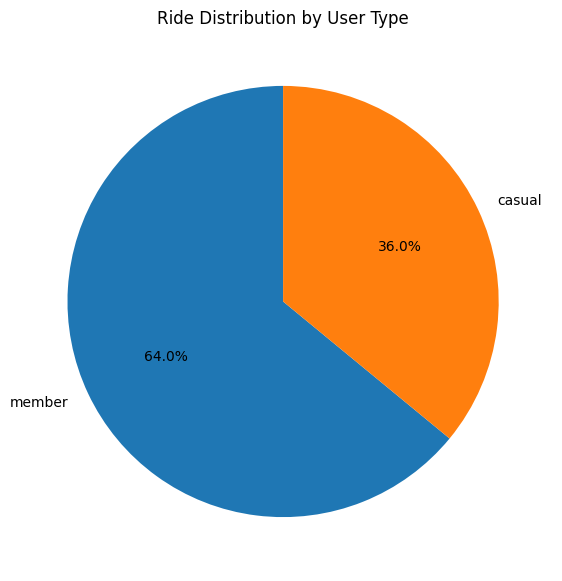

In [26]:
# Plot user type distribution as a pie chart

plt.figure(figsize=(7, 7))

plt.pie(
    user_type_counts["ride_count"],
    labels=user_type_counts["user_type"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Ride Distribution by User Type")

plt.show()

### 11.2 Ride Duration by User Type

Average and median ride duration are compared between annual members and casual riders.

In [27]:
# Calculate ride duration statistics by user type

duration_by_user = (
    df_analysis
    .groupby("member_casual")["ride_length_min"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)

duration_by_user["mean"] = duration_by_user["mean"].round(2)
duration_by_user["median"] = duration_by_user["median"].round(2)

duration_by_user

,member_casual,count,mean,median,min,max
0,casual,1994811,19.13,11.38,0.000767,1439.975950
1,member,3552569,11.95,8.58,0.001300,1439.901683


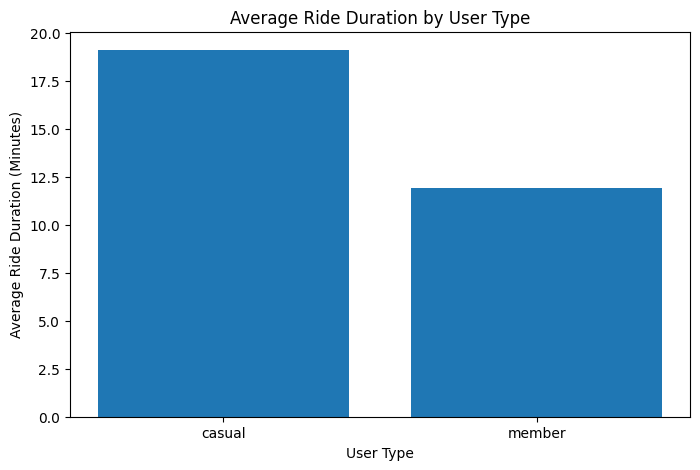

In [28]:
# Plot average ride duration by user type

plt.figure(figsize=(8, 5))

plt.bar(
    duration_by_user["member_casual"],
    duration_by_user["mean"]
)

plt.title("Average Ride Duration by User Type")
plt.xlabel("User Type")
plt.ylabel("Average Ride Duration (Minutes)")

plt.show()

### 11.3 Rides by Weekday

Ride frequency is analyzed by weekday to identify usage patterns during weekdays and weekends.

In [29]:
# Count rides by weekday and user type

rides_by_weekday = (
    df_analysis
    .groupby(["weekday", "member_casual"], observed=True)
    .size()
    .reset_index(name="ride_count")
)

rides_by_weekday

,weekday,member_casual,ride_count
0,Monday,casual,227736
1,Monday,member,502652
2,Tuesday,casual,225149
3,Tuesday,member,562949
4,Wednesday,casual,221096
5,Wednesday,member,550021
6,Thursday,casual,257518
7,Thursday,member,575857
8,Friday,casual,319282
9,Friday,member,528859


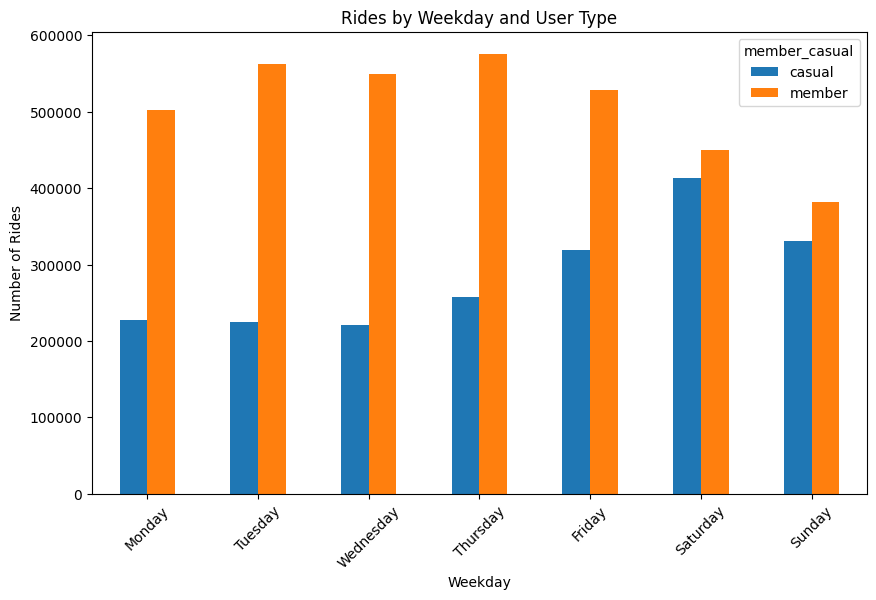

In [30]:
# Pivot data for plotting

weekday_pivot = rides_by_weekday.pivot(
    index="weekday",
    columns="member_casual",
    values="ride_count"
)

# Plot rides by weekday

weekday_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Rides by Weekday and User Type")
plt.xlabel("Weekday")
plt.ylabel("Number of Rides")
plt.xticks(rotation=45)

plt.show()

### 11.4 Average Ride Duration by Weekday

Average ride duration is compared by weekday and user type.

In [31]:
# Calculate average ride duration by weekday and user type

duration_by_weekday = (
    df_analysis
    .groupby(["weekday", "member_casual"], observed=True)["ride_length_min"]
    .mean()
    .reset_index()
)

duration_by_weekday["ride_length_min"] = duration_by_weekday["ride_length_min"].round(2)

duration_by_weekday

,weekday,member_casual,ride_length_min
0,Monday,casual,18.98
1,Monday,member,11.55
2,Tuesday,casual,16.99
3,Tuesday,member,11.63
4,Wednesday,casual,15.76
5,Wednesday,member,11.43
6,Thursday,casual,16.81
7,Thursday,member,11.51
8,Friday,casual,18.83
9,Friday,member,11.91


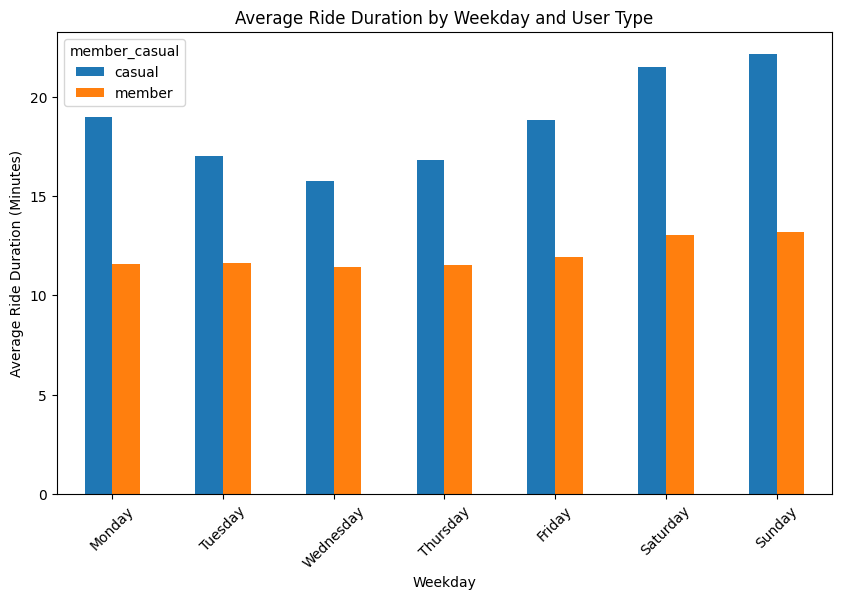

In [32]:
# Pivot data for plotting

duration_weekday_pivot = duration_by_weekday.pivot(
    index="weekday",
    columns="member_casual",
    values="ride_length_min"
)

# Plot average ride duration by weekday

duration_weekday_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Ride Duration by Weekday and User Type")
plt.xlabel("Weekday")
plt.ylabel("Average Ride Duration (Minutes)")
plt.xticks(rotation=45)

plt.show()

### 11.5 Rides by Month

Monthly ride frequency is analyzed to identify seasonal trends in bike usage.

In [33]:
# Count rides by month and user type

rides_by_month = (
    df_analysis
    .groupby(["month", "month_name", "member_casual"])
    .size()
    .reset_index(name="ride_count")
)

rides_by_month = rides_by_month.sort_values("month")

rides_by_month

,month,month_name,member_casual,ride_count
0,1,January,casual,24076
1,1,January,member,114506
2,2,February,casual,27709
3,2,February,member,124123
4,3,March,casual,85662
5,3,March,member,212226
6,4,April,casual,108971
7,4,April,member,262096
8,5,May,casual,182263
9,5,May,member,319750


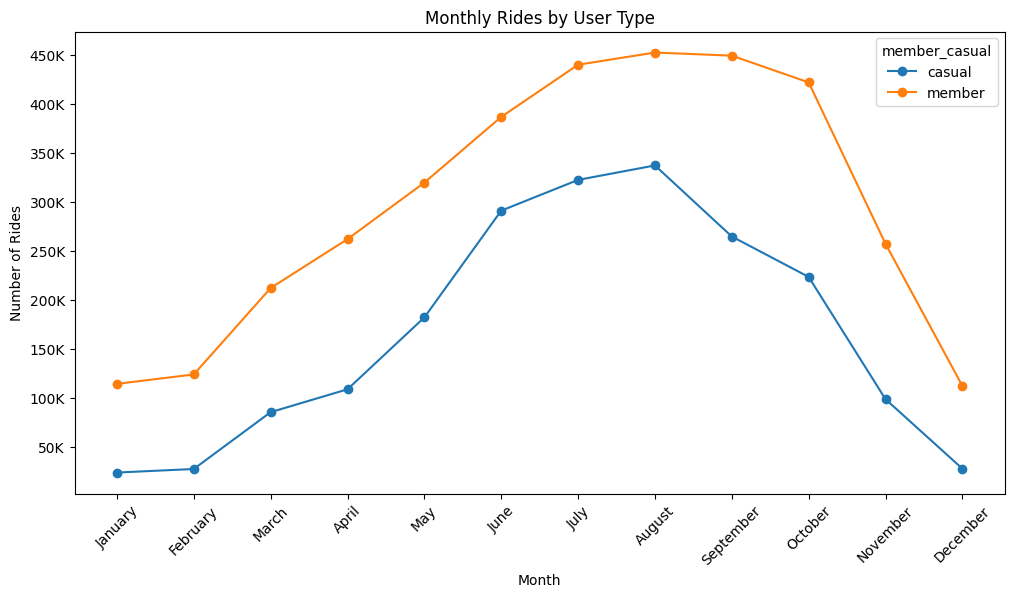

In [34]:
from matplotlib.ticker import FuncFormatter, MultipleLocator

# Monthly ride count by user type
monthly_summary = (
    df_analysis
    .groupby(["month", "month_name", "member_casual"])
    .size()
    .reset_index(name="ride_count")
    .sort_values("month")
)

# Pivot monthly data for plotting
monthly_pivot = monthly_summary.pivot(
    index="month_name",
    columns="member_casual",
    values="ride_count"
)

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_pivot = monthly_pivot.reindex(month_order)

# Plot monthly rides by user type as a line chart

ax = monthly_pivot.plot(
    kind="line",
    marker="o",
    figsize=(12, 6)
)

plt.title("Monthly Rides by User Type")
plt.xlabel("Month")
plt.ylabel("Number of Rides")

# Force all month labels to appear
ax.set_xticks(range(len(monthly_pivot.index)))
ax.set_xticklabels(monthly_pivot.index, rotation=45)

# Add more values to the Y axis
ax.yaxis.set_major_locator(MultipleLocator(50000))

# Format Y axis labels in thousands
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x/1000)}K")
)

plt.show()

### 11.6 Rides by Hour of Day

Hourly ride frequency is analyzed to compare daily usage patterns between annual members and casual riders.

In [35]:
# Count rides by hour and user type

rides_by_hour = (
    df_analysis
    .groupby(["hour", "member_casual"])
    .size()
    .reset_index(name="ride_count")
)

rides_by_hour

,hour,member_casual,ride_count
0,0,casual,38847
1,0,member,32451
2,1,casual,24892
3,1,member,19975
4,2,casual,16634
5,2,member,12007
6,3,casual,9183
7,3,member,7941
8,4,casual,7271
9,4,member,8878


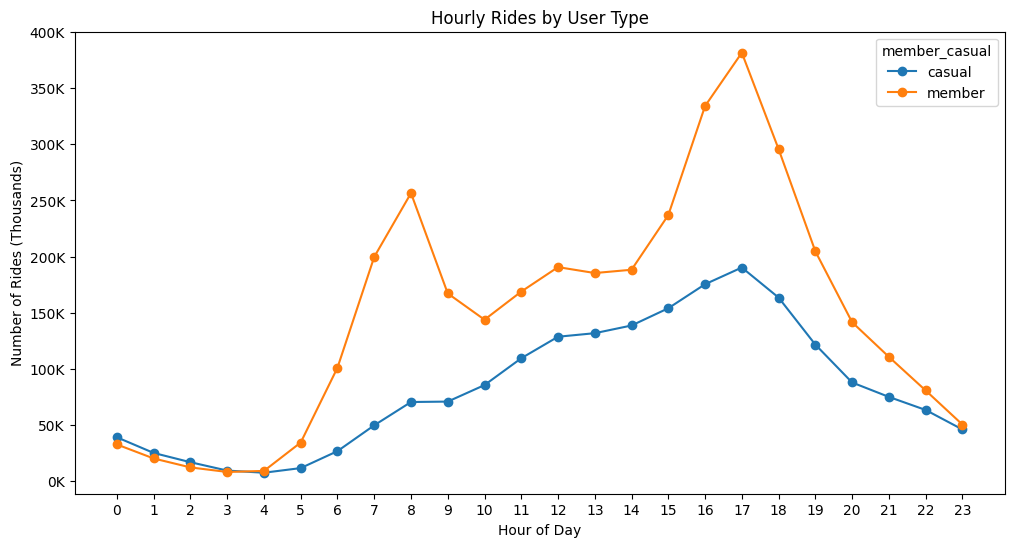

In [36]:
from matplotlib.ticker import FuncFormatter, MultipleLocator

# Pivot hourly data for plotting
hourly_pivot = rides_by_hour.pivot(
    index="hour",
    columns="member_casual",
    values="ride_count"
)

# Plot hourly rides by user type
ax = hourly_pivot.plot(
    kind="line",
    marker="o",
    figsize=(12, 6)
)

plt.title("Hourly Rides by User Type")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides (Thousands)")

# Show all hours on the X axis
plt.xticks(range(0, 24))

# Add more values to the Y axis
ax.yaxis.set_major_locator(MultipleLocator(50000))

# Format Y axis labels in thousands
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x/1000)}K")
)

plt.show()

### 11.7 Bike Type Usage

Bike type usage is compared between annual members and casual riders.

In [37]:
# Count rides by bike type and user type

bike_type_usage = (
    df_analysis
    .groupby(["rideable_type", "member_casual"])
    .size()
    .reset_index(name="ride_count")
)

bike_type_usage

,rideable_type,member_casual,ride_count
0,classic_bike,casual,667993
1,classic_bike,member,1274451
2,electric_bike,casual,1326818
3,electric_bike,member,2278118


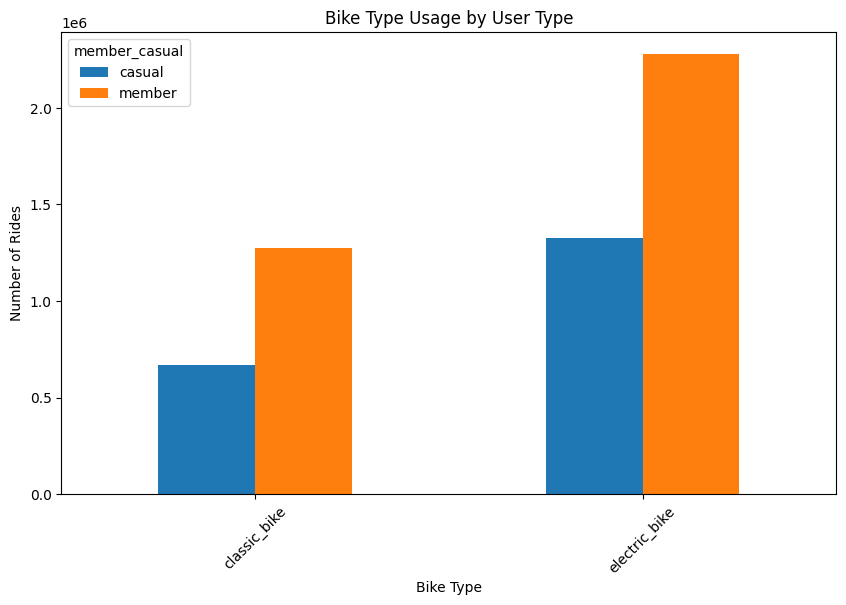

In [38]:
# Pivot data for plotting

bike_type_pivot = bike_type_usage.pivot(
    index="rideable_type",
    columns="member_casual",
    values="ride_count"
)

# Plot bike type usage

bike_type_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Bike Type Usage by User Type")
plt.xlabel("Bike Type")
plt.ylabel("Number of Rides")
plt.xticks(rotation=45)

plt.show()

### 11.8 Weekday vs Weekend Usage

Ride behavior is compared between weekdays and weekends for both user types.

In [39]:
# Count rides by weekend status and user type

weekend_usage = (
    df_analysis
    .groupby(["is_weekend", "member_casual"])
    .size()
    .reset_index(name="ride_count")
)

weekend_usage["day_type"] = weekend_usage["is_weekend"].map({
    False: "Weekday",
    True: "Weekend"
})

weekend_usage

,is_weekend,member_casual,ride_count,day_type
0,False,casual,1250781,Weekday
1,False,member,2720338,Weekday
2,True,casual,744030,Weekend
3,True,member,832231,Weekend


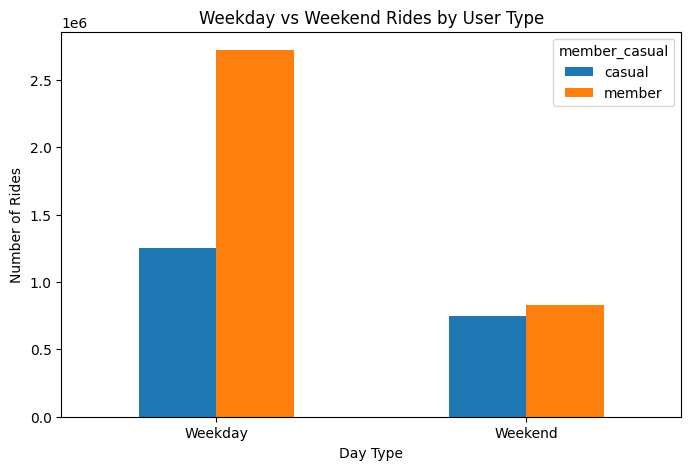

In [40]:
# Pivot data for plotting

weekend_pivot = weekend_usage.pivot(
    index="day_type",
    columns="member_casual",
    values="ride_count"
)

# Reorder index

weekend_pivot = weekend_pivot.reindex(["Weekday", "Weekend"])

# Plot weekday vs weekend usage

weekend_pivot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Weekday vs Weekend Rides by User Type")
plt.xlabel("Day Type")
plt.ylabel("Number of Rides")
plt.xticks(rotation=0)

plt.show()

### 11.9 Average Daily Rides: Weekday vs Weekend

Because weekdays include five days and weekends include only two days, total ride counts can be misleading. To make a fairer comparison, the average number of rides per day is calculated for each user type and day type.

In [41]:
# Calculate daily ride counts by date, day type, and user type

daily_daytype_usage = (
    df_analysis
    .groupby(["date", "is_weekend", "member_casual"])
    .size()
    .reset_index(name="daily_ride_count")
)

daily_daytype_usage["day_type"] = daily_daytype_usage["is_weekend"].map({
    False: "Weekday",
    True: "Weekend"
})

# Calculate average daily rides by day type and user type

avg_daily_daytype_usage = (
    daily_daytype_usage
    .groupby(["day_type", "member_casual"])["daily_ride_count"]
    .mean()
    .reset_index()
)

avg_daily_daytype_usage["daily_ride_count"] = avg_daily_daytype_usage["daily_ride_count"].round(0)

avg_daily_daytype_usage

,day_type,member_casual,daily_ride_count
0,Weekday,casual,4774.0
1,Weekday,member,10383.0
2,Weekend,casual,7154.0
3,Weekend,member,8002.0


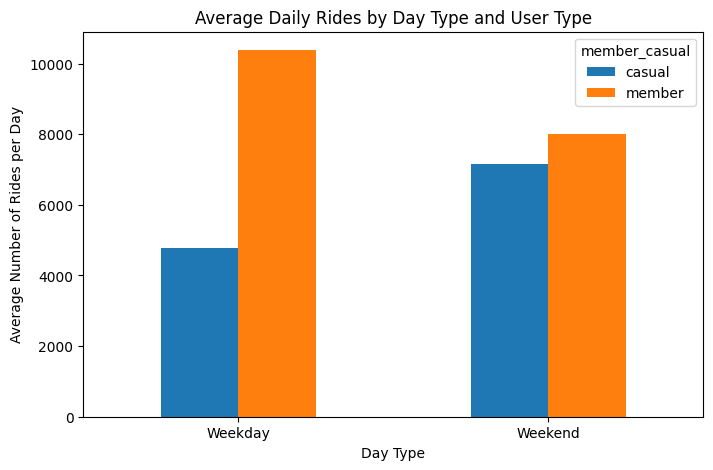

In [42]:
# Pivot data for plotting

avg_daily_daytype_pivot = avg_daily_daytype_usage.pivot(
    index="day_type",
    columns="member_casual",
    values="daily_ride_count"
)

avg_daily_daytype_pivot = avg_daily_daytype_pivot.reindex(["Weekday", "Weekend"])

# Plot average daily rides by day type

avg_daily_daytype_pivot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Daily Rides by Day Type and User Type")
plt.xlabel("Day Type")
plt.ylabel("Average Number of Rides per Day")
plt.xticks(rotation=0)

plt.show()

The weekday versus weekend comparison shows that both user types recorded more total rides during weekdays than weekends. However, this comparison should be interpreted carefully because weekdays include five days, while weekends include only two days.

Members show a stronger concentration of rides during weekdays, suggesting a more routine-based usage pattern. Casual riders also record more total rides during weekdays, but their weekend usage remains relatively high compared with members. This indicates that casual riders may be more associated with leisure or occasional trips, especially on Saturdays and Sundays.

## 12. Save Analysis Outputs

The main summary tables are saved as CSV files for future use in reports, presentations, or GitHub documentation.

In [43]:
# Save summary tables as CSV files

user_type_counts.to_csv(outputs_path + "/user_type_counts.csv", index=False)
duration_by_user.to_csv(outputs_path + "/duration_by_user.csv", index=False)
rides_by_weekday.to_csv(outputs_path + "/rides_by_weekday.csv", index=False)
duration_by_weekday.to_csv(outputs_path + "/duration_by_weekday.csv", index=False)
rides_by_month.to_csv(outputs_path + "/rides_by_month.csv", index=False)
rides_by_hour.to_csv(outputs_path + "/rides_by_hour.csv", index=False)
bike_type_usage.to_csv(outputs_path + "/bike_type_usage.csv", index=False)
weekend_usage.to_csv(outputs_path + "/weekend_usage.csv", index=False)

print("Analysis output tables saved successfully")

Analysis output tables saved successfully


In [44]:
user_type_counts

,user_type,ride_count,percentage
0,member,3552569,64.04
1,casual,1994811,35.96


## 13. Monthly and Hourly Usage Patterns

This section analyzes ride patterns by month and hour of the day. These patterns help identify seasonality and daily usage behavior among annual members and casual riders.

In [45]:
from matplotlib.ticker import FuncFormatter, MultipleLocator

### 13.1 Monthly Usage Patterns

Monthly ride frequency is analyzed to identify seasonal trends in bike usage among annual members and casual riders.

In [46]:
# Monthly ride count by user type

monthly_summary = (
    df_analysis
    .groupby(["month", "month_name", "member_casual"])
    .size()
    .reset_index(name="ride_count")
    .sort_values("month")
)

monthly_summary

,month,month_name,member_casual,ride_count
0,1,January,casual,24076
1,1,January,member,114506
2,2,February,casual,27709
3,2,February,member,124123
4,3,March,casual,85662
5,3,March,member,212226
6,4,April,casual,108971
7,4,April,member,262096
8,5,May,casual,182263
9,5,May,member,319750


In [47]:
# Pivot monthly data for plotting

monthly_pivot = monthly_summary.pivot(
    index="month_name",
    columns="member_casual",
    values="ride_count"
)

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_pivot = monthly_pivot.reindex(month_order)

monthly_pivot

member_casual,casual,member
month_name,,
January,24076,114506
February,27709,124123
March,85662,212226
April,108971,262096
May,182263,319750
June,291138,386709
July,322505,439965
August,337246,452355
September,264772,449202


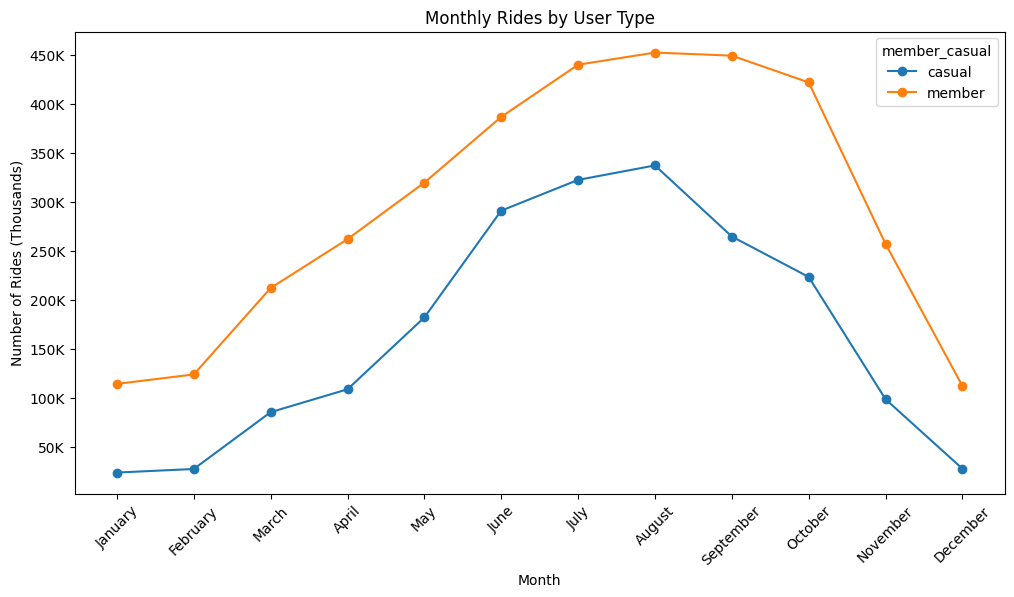

In [48]:
# Plot monthly rides by user type as a line chart

ax = monthly_pivot.plot(
    kind="line",
    marker="o",
    figsize=(12, 6)
)

plt.title("Monthly Rides by User Type")
plt.xlabel("Month")
plt.ylabel("Number of Rides (Thousands)")

# Force all month labels to appear
ax.set_xticks(range(len(monthly_pivot.index)))
ax.set_xticklabels(monthly_pivot.index, rotation=45)

# Add more values to the Y axis
ax.yaxis.set_major_locator(MultipleLocator(50000))

# Format Y axis labels in thousands
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x/1000)}K")
)

plt.show()

### 13.2 Hourly Usage Patterns

Ride frequency is analyzed by hour of the day to identify differences in daily usage patterns between annual members and casual riders.

### Key Findings: Monthly and Hourly Usage Patterns

Monthly ride patterns show a clear seasonal trend. Both annual members and casual riders increased their bike usage during the warmer months, especially between June and September. Casual riders reached their highest number of rides in August, followed by July and June. Members also recorded their highest usage in August, September, July, and October.

Hourly usage patterns reveal important differences between both user types. Members show strong peaks during commuting hours, especially around 8:00 AM and between 4:00 PM and 6:00 PM. This suggests that annual members are more likely to use Cyclistic bikes for routine transportation, such as commuting to work or school.

Casual riders also peak in the afternoon and early evening, especially between 2:00 PM and 6:00 PM. However, their usage pattern is less concentrated around the morning commute. This suggests that casual riders may be more likely to use bikes for leisure, tourism, errands, or occasional trips rather than daily commuting.


In [49]:
# Hourly ride count by user type

hourly_summary = (
    df_analysis
    .groupby(["hour", "member_casual"])
    .size()
    .reset_index(name="ride_count")
)

hourly_summary

,hour,member_casual,ride_count
0,0,casual,38847
1,0,member,32451
2,1,casual,24892
3,1,member,19975
4,2,casual,16634
5,2,member,12007
6,3,casual,9183
7,3,member,7941
8,4,casual,7271
9,4,member,8878


In [50]:
# Pivot hourly data for plotting

hourly_pivot = hourly_summary.pivot(
    index="hour",
    columns="member_casual",
    values="ride_count"
)

hourly_pivot

member_casual,casual,member
hour,,
0,38847,32451
1,24892,19975
2,16634,12007
3,9183,7941
4,7271,8878
5,11408,34201
6,26523,100906
7,49547,199688
8,70313,256538


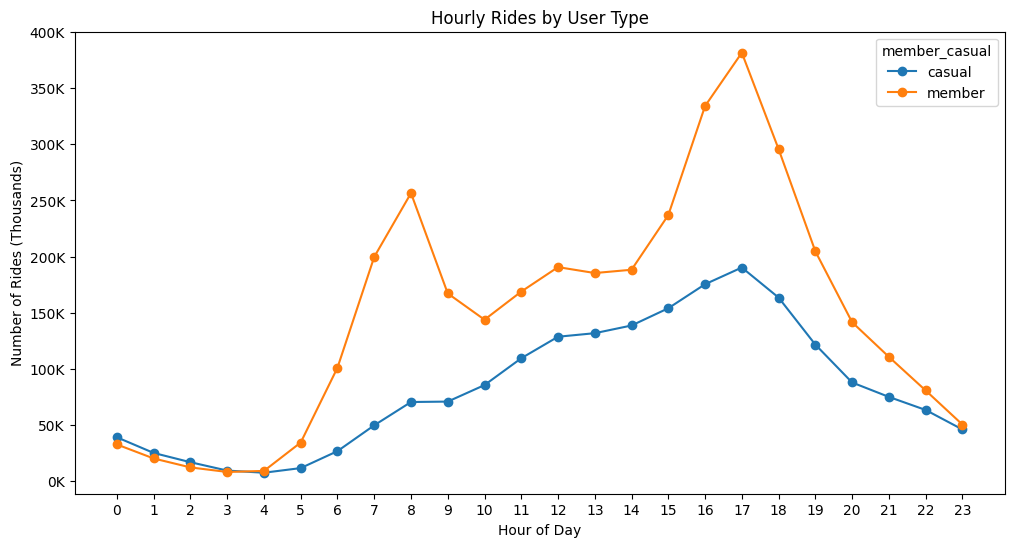

In [51]:
# Plot hourly rides by user type as a line chart

ax = hourly_pivot.plot(
    kind="line",
    marker="o",
    figsize=(12, 6)
)

plt.title("Hourly Rides by User Type")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides (Thousands)")

# Show all hours on the X axis
plt.xticks(range(0, 24))

# Add more values to the Y axis
ax.yaxis.set_major_locator(MultipleLocator(50000))

# Format Y axis labels in thousands
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x/1000)}K")
)

plt.show()

### 13.3 Peak Usage Hours

The top usage hours are identified for each user type to better understand when members and casual riders are most active.

In [52]:
# Identify peak usage hours by user type

peak_hours = (
    hourly_summary
    .sort_values(["member_casual", "ride_count"], ascending=[True, False])
    .groupby("member_casual")
    .head(5)
)

peak_hours

,hour,member_casual,ride_count
34,17,casual,190219
32,16,casual,175326
36,18,casual,163420
30,15,casual,153911
28,14,casual,138529
35,17,member,381720
33,16,member,334185
37,18,member,295816
17,8,member,256538
31,15,member,236970


### Key Findings: Monthly and Hourly Usage Patterns

Monthly ride patterns show a clear seasonal trend. Both annual members and casual riders increased their bike usage during the warmer months, especially between June and September. Casual riders reached their highest number of rides in August, followed by July and June. Members also recorded their highest usage in August, September, July, and October.

Hourly usage patterns reveal important differences between both user types. Members show strong peaks during commuting hours, especially around 8:00 AM and between 4:00 PM and 6:00 PM. This suggests that annual members are more likely to use Cyclistic bikes for routine transportation, such as commuting to work or school.

Casual riders also peak in the afternoon and early evening, especially between 2:00 PM and 6:00 PM. However, their usage pattern is less concentrated around the morning commute. This suggests that casual riders may be more likely to use bikes for leisure, tourism, errands, or occasional trips rather than daily commuting.

## 14. Bike Type Usage

This section compares the use of different bike types between annual members and casual riders.

In [53]:
# Count rides by bike type and user type

bike_type_summary = (
    df_analysis
    .groupby(["rideable_type", "member_casual"])
    .size()
    .reset_index(name="ride_count")
)

bike_type_summary

,rideable_type,member_casual,ride_count
0,classic_bike,casual,667993
1,classic_bike,member,1274451
2,electric_bike,casual,1326818
3,electric_bike,member,2278118


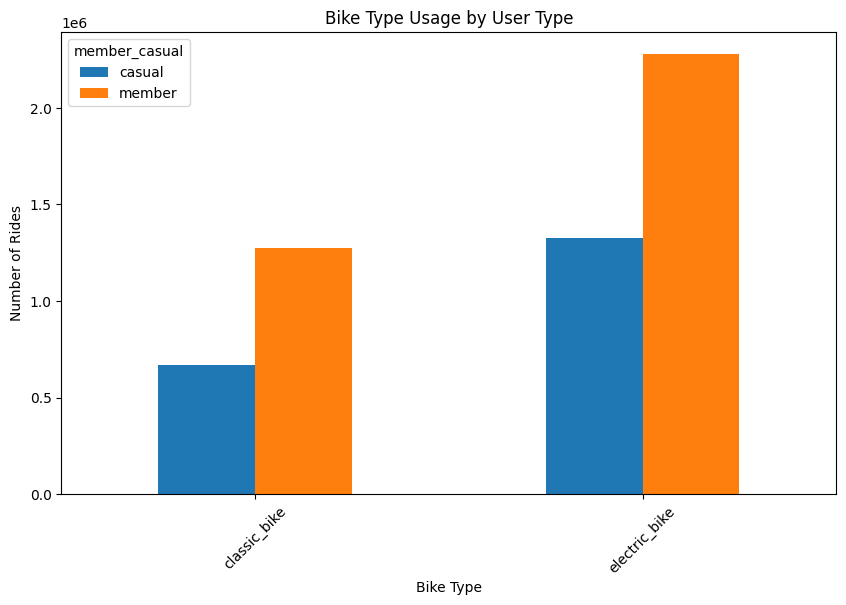

In [54]:
# Pivot bike type data for plotting

bike_type_pivot = bike_type_summary.pivot(
    index="rideable_type",
    columns="member_casual",
    values="ride_count"
)

# Plot bike type usage by user type

bike_type_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Bike Type Usage by User Type")
plt.xlabel("Bike Type")
plt.ylabel("Number of Rides")
plt.xticks(rotation=45)

plt.show()

In [55]:
# Calculate bike type percentage within each user type

bike_type_percentage = bike_type_summary.copy()

bike_type_percentage["percentage"] = (
    bike_type_percentage["ride_count"] /
    bike_type_percentage.groupby("member_casual")["ride_count"].transform("sum") * 100
).round(2)

bike_type_percentage

,rideable_type,member_casual,ride_count,percentage
0,classic_bike,casual,667993,33.49
1,classic_bike,member,1274451,35.87
2,electric_bike,casual,1326818,66.51
3,electric_bike,member,2278118,64.13


### Key Findings: Bike Type Usage

Both annual members and casual riders used electric bikes more frequently than classic bikes in 2025. Electric bikes represented 66.51% of casual rider trips and 64.13% of member trips.

Although members recorded more rides than casual riders for both bike types, the percentage distribution is relatively similar across the two groups. This suggests that bike type preference is not the main difference between annual members and casual riders.

The main behavioral differences appear to be related more strongly to ride frequency, ride duration, weekday patterns, monthly seasonality, and hourly usage rather than bike type selection.


## 15. Summary of Key Findings

This section summarizes the main findings from the analysis and connects them to the business question: how do annual members and casual riders use Cyclistic bikes differently?

### Summary of Key Findings

The analysis shows clear behavioral differences between annual members and casual riders.

First, annual members accounted for most rides in 2025, with 3,552,569 rides, representing 64.04% of total trips. Casual riders completed 1,994,811 rides, representing 35.96% of total trips.

Second, casual riders took longer trips than annual members. Casual riders had an average ride duration of 19.13 minutes, compared with 11.95 minutes for members. The median ride duration also followed the same pattern, with casual riders recording longer trips than members.

Third, weekday usage patterns suggest that members use Cyclistic more consistently throughout the week, especially during weekdays. This may indicate routine-based transportation behavior, such as commuting or regular daily trips. Casual riders also use the service during weekdays, but their relative usage is stronger during weekends compared with members.

Fourth, monthly ride patterns show a strong seasonal trend. Both user groups increased bike usage during warmer months, especially between June and September. Casual riders reached their highest number of rides in August, while members recorded high usage in August, September, July, and October.

Fifth, hourly usage patterns suggest different trip purposes. Members show clear peaks around commuting hours, especially around 8:00 AM and between 4:00 PM and 6:00 PM. Casual riders peak mainly in the afternoon and early evening, especially between 2:00 PM and 6:00 PM, which may reflect leisure, tourism, errands, or occasional trips.

Finally, bike type usage does not appear to be the main difference between both groups. Both members and casual riders used electric bikes more frequently than classic bikes, with similar percentage distributions across user types.


## 16. Business Recommendations

Based on the findings, the following recommendations are proposed to help convert casual riders into annual members.

### Business Recommendations

1. Launch seasonal membership campaigns during high-demand months.

Casual rider activity increases strongly during warmer months, especially between June and September. Cyclistic could launch targeted membership campaigns before and during this period, highlighting the value of becoming an annual member for frequent summer riders.

2. Target casual riders during weekends and leisure-oriented trips.

Casual riders show relatively stronger weekend usage compared with members and tend to take longer trips. Marketing campaigns could focus on users who ride on weekends, promoting annual memberships as a convenient and cost-effective option for regular leisure, tourism, or recreational trips.

3. Promote membership benefits during afternoon and early evening usage peaks.

Casual riders are most active between 2:00 PM and 6:00 PM. Cyclistic could use in-app messages, email campaigns, or station-based promotions during these time windows to encourage casual riders to consider annual membership plans.

4. Create trial or flexible membership options for casual riders.

Since casual riders may not immediately identify as daily commuters, Cyclistic could offer trial memberships, seasonal passes, or discounted first-month annual plans. This could reduce the barrier to conversion and help casual riders experience the benefits of membership.

5. Emphasize cost savings for frequent casual riders.

Because casual riders take longer trips and may use bikes repeatedly during high-demand months, Cyclistic could personalize marketing messages showing how much frequent casual riders could save by switching to an annual membership.


## 17. Conclusion

### Conclusion

The analysis indicates that annual members and casual riders use Cyclistic bikes differently. Members appear to use the service more frequently and consistently, with patterns that suggest routine transportation and commuting behavior. Casual riders, on the other hand, tend to take longer trips and show stronger usage during warmer months, weekends, and afternoon hours.

These findings suggest that Cyclistic should focus its marketing strategy on casual riders who already show repeated or high-value usage patterns, especially during summer months, weekends, and afternoon periods. By targeting these users with seasonal campaigns, flexible membership options, and personalized cost-saving messages, Cyclistic may increase the conversion of casual riders into annual members.


## 18. Save Visualizations

The main visualizations are saved as PNG files in the outputs folder. These files can be used later in the GitHub repository, reports, or presentations.

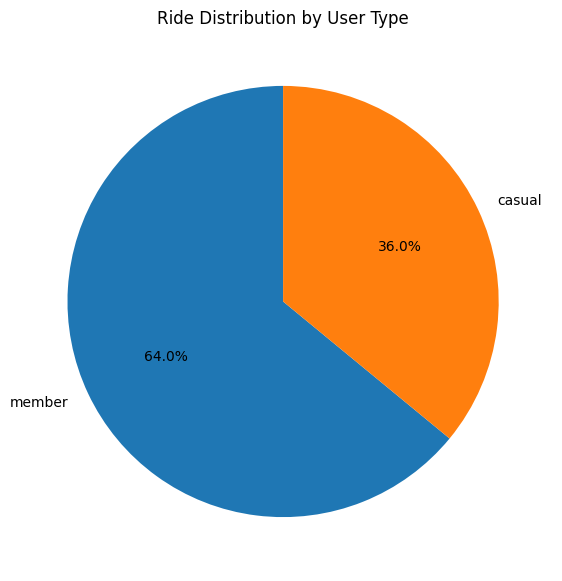

In [56]:
from matplotlib.ticker import FuncFormatter, MultipleLocator

# Save User Type Distribution pie chart

plt.figure(figsize=(7, 7))

plt.pie(
    user_type_counts["ride_count"],
    labels=user_type_counts["user_type"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Ride Distribution by User Type")
plt.savefig(outputs_path + "/ride_distribution_by_user_type.png", dpi=300, bbox_inches="tight")
plt.show()

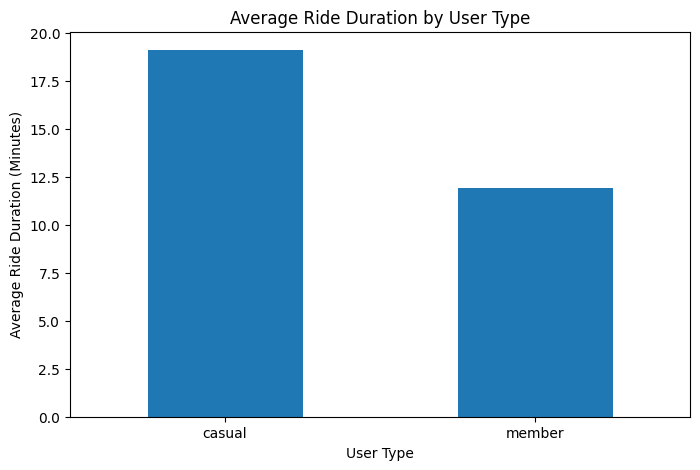

In [57]:
# Save Average Ride Duration by User Type chart

ax = duration_by_user.plot(
    x="member_casual",
    y="mean",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)

plt.title("Average Ride Duration by User Type")
plt.xlabel("User Type")
plt.ylabel("Average Ride Duration (Minutes)")
plt.xticks(rotation=0)

plt.savefig(outputs_path + "/average_ride_duration_by_user_type.png", dpi=300, bbox_inches="tight")
plt.show()

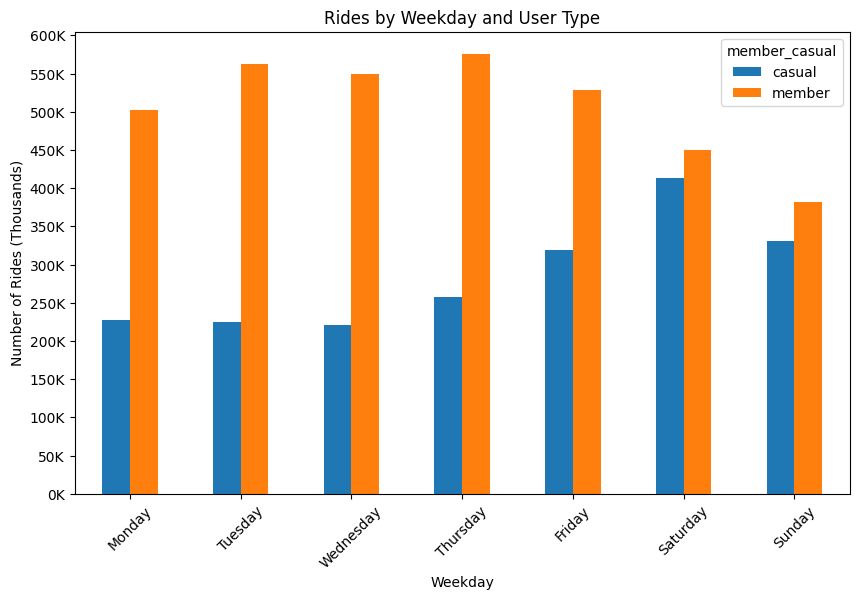

In [58]:
# Save Rides by Weekday and User Type chart

ax = weekday_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Rides by Weekday and User Type")
plt.xlabel("Weekday")
plt.ylabel("Number of Rides (Thousands)")
plt.xticks(rotation=45)

ax.yaxis.set_major_locator(MultipleLocator(50000))
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x/1000)}K")
)

plt.savefig(outputs_path + "/rides_by_weekday_and_user_type.png", dpi=300, bbox_inches="tight")
plt.show()

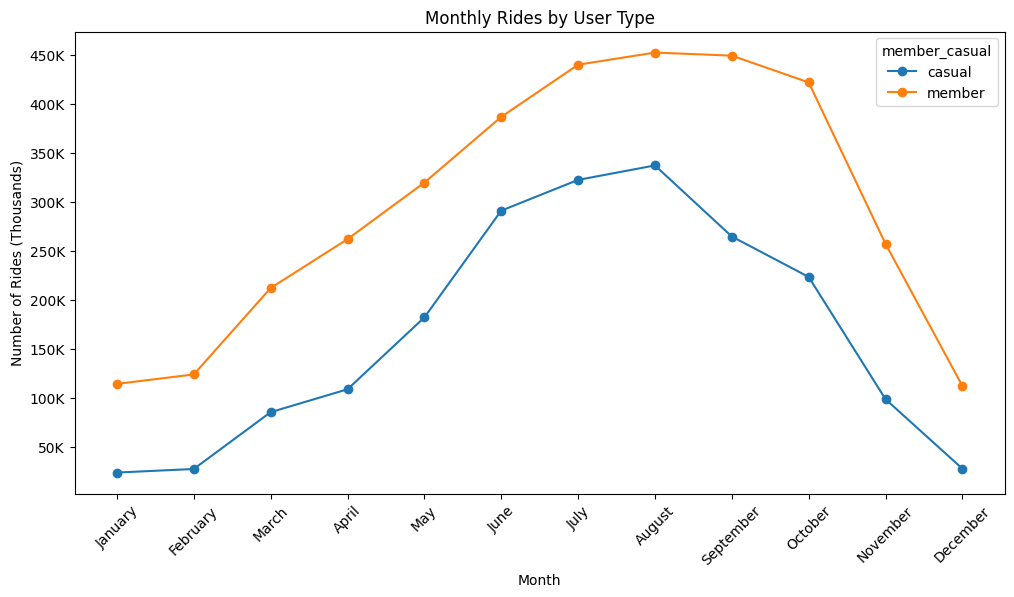

In [59]:
# Save Monthly Rides by User Type chart

ax = monthly_pivot.plot(
    kind="line",
    marker="o",
    figsize=(12, 6)
)

plt.title("Monthly Rides by User Type")
plt.xlabel("Month")
plt.ylabel("Number of Rides (Thousands)")

ax.set_xticks(range(len(monthly_pivot.index)))
ax.set_xticklabels(monthly_pivot.index, rotation=45)

ax.yaxis.set_major_locator(MultipleLocator(50000))
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x/1000)}K")
)

plt.savefig(outputs_path + "/monthly_rides_by_user_type.png", dpi=300, bbox_inches="tight")
plt.show()

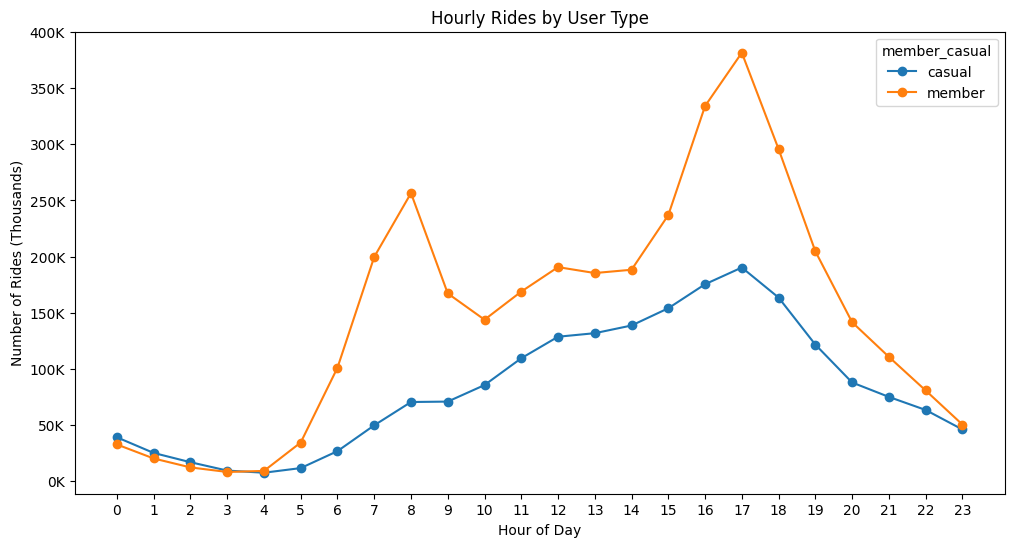

In [60]:
# Save Hourly Rides by User Type chart

ax = hourly_pivot.plot(
    kind="line",
    marker="o",
    figsize=(12, 6)
)

plt.title("Hourly Rides by User Type")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides (Thousands)")
plt.xticks(range(0, 24))

ax.yaxis.set_major_locator(MultipleLocator(50000))
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x/1000)}K")
)

plt.savefig(outputs_path + "/hourly_rides_by_user_type.png", dpi=300, bbox_inches="tight")
plt.show()

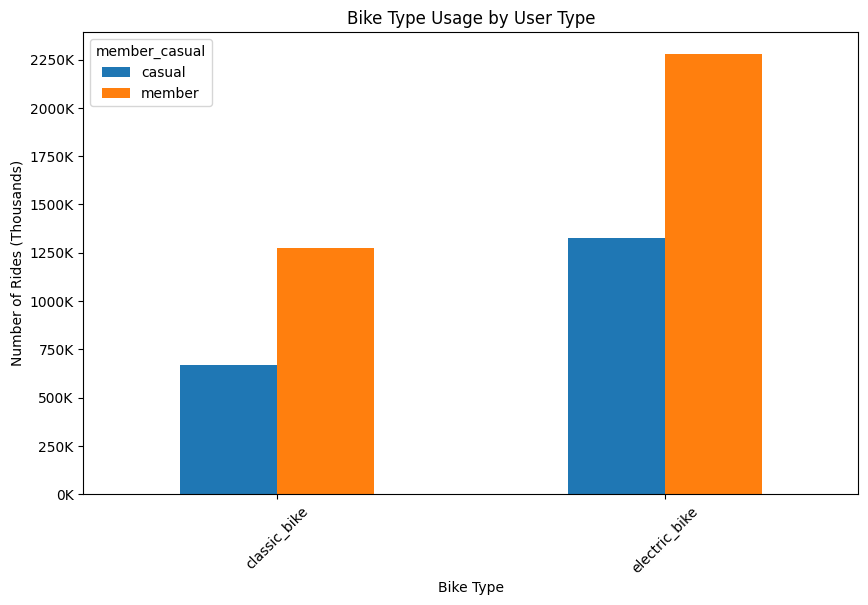

In [61]:
# Save Bike Type Usage by User Type chart

ax = bike_type_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Bike Type Usage by User Type")
plt.xlabel("Bike Type")
plt.ylabel("Number of Rides (Thousands)")
plt.xticks(rotation=45)

# Use wider intervals because values are above 2 million
ax.yaxis.set_major_locator(MultipleLocator(250000))

# Format Y axis labels in thousands
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x/1000)}K")
)

plt.savefig(outputs_path + "/bike_type_usage_by_user_type.png", dpi=300, bbox_inches="tight")
plt.show()

In [62]:
# Check saved output files

import os

for file in os.listdir(outputs_path):
    print(file)

user_type_counts.csv
duration_by_user.csv
rides_by_weekday.csv
duration_by_weekday.csv
rides_by_month.csv
rides_by_hour.csv
bike_type_usage.csv
weekend_usage.csv
ride_distribution_by_user_type.png
average_ride_duration_by_user_type.png
rides_by_weekday_and_user_type.png
monthly_rides_by_user_type.png
hourly_rides_by_user_type.png
bike_type_usage_by_user_type.png


## 19. Final Project Check

This final section checks the cleaned dataset size and confirms that the main output files were saved successfully.

In [63]:
# Final dataset size

print("Final cleaned dataset shape:", df_clean.shape)

Final cleaned dataset shape: (5547380, 22)


In [64]:
# Check saved output files

import os

output_files = os.listdir(outputs_path)

for file in output_files:
    print(file)

user_type_counts.csv
duration_by_user.csv
rides_by_weekday.csv
duration_by_weekday.csv
rides_by_month.csv
rides_by_hour.csv
bike_type_usage.csv
weekend_usage.csv
ride_distribution_by_user_type.png
average_ride_duration_by_user_type.png
rides_by_weekday_and_user_type.png
monthly_rides_by_user_type.png
hourly_rides_by_user_type.png
bike_type_usage_by_user_type.png


## 20. Project Completion

The analysis was completed using Python in Google Colab. The project included data loading, data cleaning, exploratory data analysis, visualization, and business recommendations.

The cleaned dataset contains valid bike-share trips for 2025 and was used to compare annual members and casual riders. The final outputs include summary tables and visualizations that can be used in a GitHub repository, report, or presentation.